Number of GPUs available: 2

[Loading MNIST dataset via torchvision...]


100%|██████████| 9.91M/9.91M [00:00<00:00, 37.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.00MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


Distributing dataset to GPUs...
Dataset shape per GPU: torch.Size([784, 5000, 10])

EVALUATING ALGORITHMS ACROSS RANKS 1 TO 70 (DUAL GPU)


/tmp/ipykernel_58/1121225286.py:39: UserWarning: Attempting to run cuFFT, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/native/cuda/SpectralOps.cpp:256.)
  A_f = torch.fft.fft(A, dim=2)


[Done] Rank  1 | Handled by GPU 1 | Hybrid PSNR: 12.96 dB
[Done] Rank  2 | Handled by GPU 0 | Hybrid PSNR: 13.43 dB
[Done] Rank  4 | Handled by GPU 0 | Hybrid PSNR: 14.10 dB
[Done] Rank  3 | Handled by GPU 1 | Hybrid PSNR: 13.77 dB
[Done] Rank  6 | Handled by GPU 0 | Hybrid PSNR: 14.67 dB
[Done] Rank  5 | Handled by GPU 1 | Hybrid PSNR: 14.38 dB
[Done] Rank  8 | Handled by GPU 0 | Hybrid PSNR: 15.29 dB
[Done] Rank  7 | Handled by GPU 1 | Hybrid PSNR: 14.96 dB
[Done] Rank 10 | Handled by GPU 0 | Hybrid PSNR: 15.93 dB
[Done] Rank  9 | Handled by GPU 1 | Hybrid PSNR: 15.60 dB
[Done] Rank 12 | Handled by GPU 0 | Hybrid PSNR: 16.58 dB
[Done] Rank 11 | Handled by GPU 1 | Hybrid PSNR: 16.24 dB
[Done] Rank 14 | Handled by GPU 0 | Hybrid PSNR: 17.29 dB
[Done] Rank 13 | Handled by GPU 1 | Hybrid PSNR: 16.94 dB
[Done] Rank 16 | Handled by GPU 0 | Hybrid PSNR: 18.04 dB
[Done] Rank 15 | Handled by GPU 1 | Hybrid PSNR: 17.67 dB
[Done] Rank 18 | Handled by GPU 0 | Hybrid PSNR: 18.79 dB
[Done] Rank 17

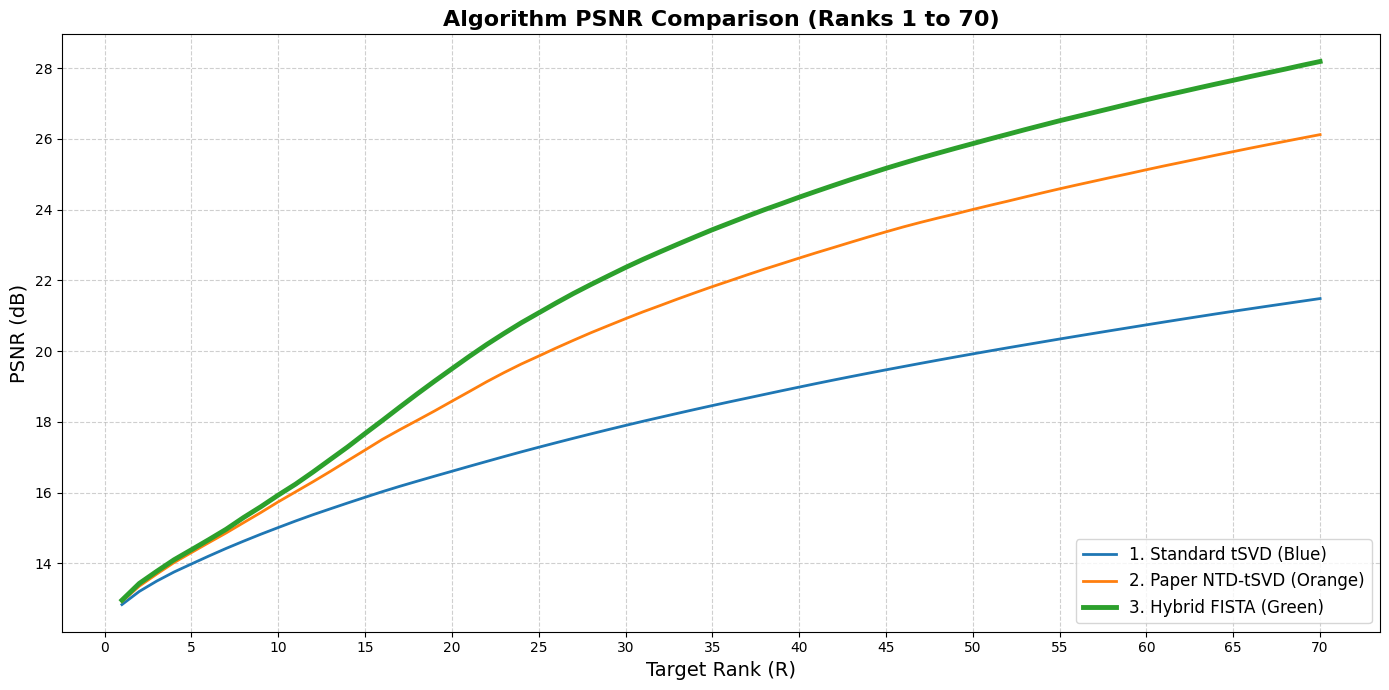

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import concurrent.futures

torch.backends.cuda.matmul.allow_tf32 = True

print(f"Number of GPUs available: {torch.cuda.device_count()}")
if torch.cuda.device_count() < 2:
    print("WARNING: Only 1 GPU detected.")

# 1. TENSOR OPERATIONS (GPU-Agnostic)
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)
    
    curr_dev = A.device 

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=curr_dev)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=curr_dev)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=curr_dev)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t

# 2. ALGORITHMS

# Standard tSVD
def Standard_tSVD(M, R=30):
    U, S, V = tsvd(M)
    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]
    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# NTD-tSVD 
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        X_k = tprod(tprod(U_r, S_r), tran(V_r))

    return X_k

# Hybrid FISTA 
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P

# 3. UTILITIES & VISUALIZATION

def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_psnr_vs_rank(ranks, psnr_tsvd, psnr_paper, psnr_hybrid, best_rank):
    plt.figure(figsize=(14, 7))

    plt.plot(ranks, psnr_tsvd, linestyle='-', linewidth=2, color='#1f77b4', label='1. Standard tSVD (Blue)')
    plt.plot(ranks, psnr_paper, linestyle='-', linewidth=2, color='#ff7f0e', label='2. Paper NTD-tSVD (Orange)')
    plt.plot(ranks, psnr_hybrid, linestyle='-', linewidth=3.5, color='#2ca02c', label='3. Hybrid FISTA (Green)')

    plt.title('Algorithm PSNR Comparison (Ranks 1 to 70)', fontsize=16, fontweight='bold')
    plt.xlabel('Target Rank (R)', fontsize=14)
    plt.ylabel('PSNR (dB)', fontsize=14)

    plt.xticks(list(range(0, max(ranks) + 5, 5)))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12, loc='lower right')
    plt.tight_layout()
    plt.show()

# 4. DATA PREPARATION 

print("\n[Loading MNIST dataset via torchvision...]")
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

num_samples = 5000
tensor_mnist_cpu = torch.zeros((784, num_samples, 10))

for digit in range(10):
    idx = (mnist_train.targets == digit)
    imgs = mnist_train.data[idx].float() / 255.0
    actual = min(num_samples, len(imgs))
    tensor_mnist_cpu[:, :actual, digit] = imgs[:actual].reshape(actual, 784).T

print("Distributing dataset to GPUs...")
tensor_gpu0 = tensor_mnist_cpu.to('cuda:0')
if torch.cuda.device_count() > 1:
    tensor_gpu1 = tensor_mnist_cpu.to('cuda:1')
else:
    tensor_gpu1 = tensor_gpu0 

print("Dataset shape per GPU:", tensor_gpu0.shape)


# 5. MULTI-GPU MULTI-RANK EXECUTION (1 to 70)

RANKS_TO_TEST = list(range(1, 71))

print(f"\n=======================================================")
print(f"EVALUATING ALGORITHMS ACROSS RANKS 1 TO 70 (DUAL GPU)")
print(f"=======================================================")

def evaluate_single_rank(R):
    gpu_id = R % 2
    curr_tensor = tensor_gpu1 if gpu_id == 1 else tensor_gpu0
    
    # 1. Standard tSVD
    P_recon_tsvd = Standard_tSVD(curr_tensor, R=R)
    final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
    val_tsvd = calculate_psnr(curr_tensor, final_tsvd)

    # 2. NTD-1SVD
    P_recon_paper = NTD_1SVD_Paper(curr_tensor, R=R, maxiters=50)
    final_paper = torch.clamp(P_recon_paper, 0, 1)
    val_paper = calculate_psnr(curr_tensor, final_paper)

    # 3. Hybrid FISTA 
    P_recon_hybrid = NTD_tSVD_FISTA_Optimized(curr_tensor, R=R, alpha=0.2, alpha_decay=0.90, maxiters=50)
    final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
    val_hybrid = calculate_psnr(curr_tensor, final_hybrid)
    
    print(f"[Done] Rank {R:2d} | Handled by GPU {gpu_id} | Hybrid PSNR: {val_hybrid:.2f} dB")
    
    return R, val_tsvd, val_paper, val_hybrid

results = []

with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
    futures = [executor.submit(evaluate_single_rank, R) for R in RANKS_TO_TEST]
    for future in concurrent.futures.as_completed(futures):
        results.append(future.result())


results.sort(key=lambda x: x[0])

psnrs_tsvd = [res[1] for res in results]
psnrs_paper = [res[2] for res in results]
psnrs_hybrid = [res[3] for res in results]

plot_psnr_vs_rank(RANKS_TO_TEST, psnrs_tsvd, psnrs_paper, psnrs_hybrid, best_overall_rank)